<a href="https://colab.research.google.com/github/s0963718122-blip/02/blob/main/D2AI%E9%80%A0%E7%A2%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:

# 提供一個輸入介面讓使用者修改股票代碼
new_ticker_symbol = input("請輸入新的股票代碼 (例如：2330.TW 或 TSM): ")

# 檢查輸入是否為空，如果不為空則更新 ticker_symbol
if new_ticker_symbol:
    ticker_symbol = new_ticker_symbol
    print(f"股票代碼已更新為: {ticker_symbol}")
else:
    print(f"未輸入新的股票代碼，目前使用的代碼為: {ticker_symbol}")

請輸入新的股票代碼 (例如：2330.TW 或 TSM): 00981A.TW
股票代碼已更新為: 00981A.TW


執行上述儲存格後，您可以再次執行繪圖的儲存格 (`68215353`)，以新的股票代碼顯示數據。

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import matplotlib.font_manager # Import font_manager

# Install a CJK-compatible font for matplotlib
!apt-get -y install fonts-wqy-zenhei

# Clear matplotlib's font cache
cache_dir = mpl.get_cachedir()
cache_file = os.path.join(cache_dir, 'fontlist-v330.json') # The version might vary
if os.path.exists(cache_file):
    os.remove(cache_file)
    print(f"Removed matplotlib font cache: {cache_file}")

# Configure matplotlib to use the installed font, explicitly setting 'WenQuanYi Zen Hei'
mpl.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei'] # Removed DejaVu Sans as a direct fallback
mpl.rcParams['axes.unicode_minus'] = False # This handles the minus sign correctly

print("Matplotlib font configuration updated.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-wqy-zenhei is already the newest version (0.9.45-8).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
Matplotlib font configuration updated.


In [23]:
pip install yfinance

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24163 (\N{CJK UN

Price          Close      High       Low      Open    Volume
Ticker     00981A.TW 00981A.TW 00981A.TW 00981A.TW 00981A.TW
Date                                                        
2025-05-27  9.689956  9.787932  9.680158  9.758540  58189907
2025-05-28  9.738944  9.807529  9.729147  9.787933  32181740
2025-05-29  9.856517  9.866314  9.787932  9.836921  64400020
2025-06-02  9.729147  9.797731  9.680158  9.778135  19924770
2025-06-03  9.827124  9.905505  9.807529  9.807529  21577800


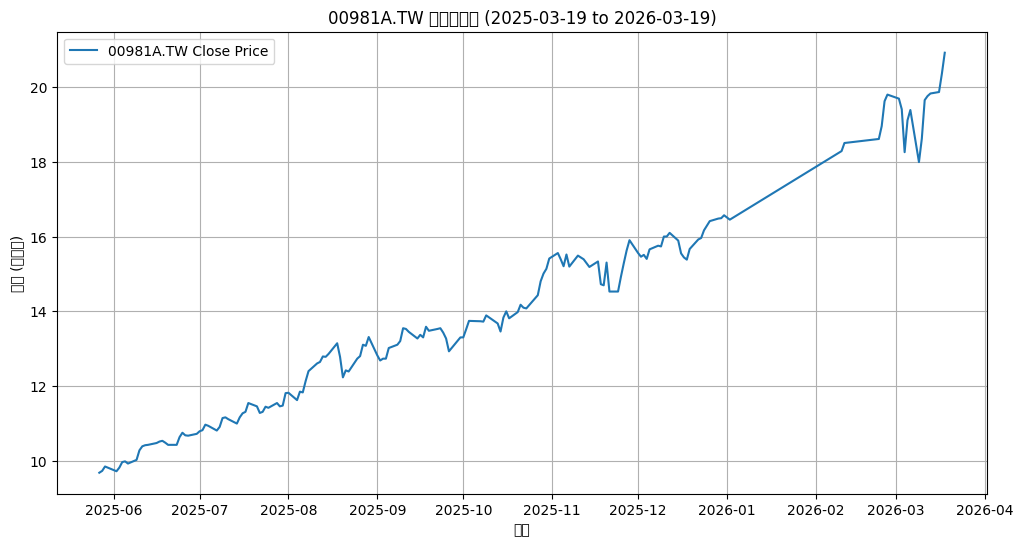

In [24]:
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Calculate the date range for the last year
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

# Get historical stock data for the current ticker_symbol
tsmc_data = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True)

# Display the first few rows of data
print(tsmc_data.head())

# Plot the closing price trend
plt.figure(figsize=(12, 6))
plt.plot(tsmc_data['Close'], label=f'{ticker_symbol} Close Price')
plt.title(f'{ticker_symbol} 股價走勢圖 ({start_date} to {end_date})')
plt.xlabel('日期')
plt.ylabel('股價 (新台幣)')
plt.grid(True)
plt.legend()
plt.show()